In [ ]:
import pandas as pd

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 读取文件并提取数据
def extract_reward_data(filename):
    """
    从文件中提取step和reward数据
    """
    steps = []
    rewards = []
    grads = []
    
    # 使用正则表达式匹配需要的行
    pattern = r'\[Step (\d+)/\d+\] reward=([0-9.]+), grad=([0-9.]+)'
    
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            match = re.search(pattern, line)
            if match:
                step = int(match.group(1))
                reward = float(match.group(2))
                grad = float(match.group(3))
                
                steps.append(step)
                rewards.append(reward)
                grads.append(grad)
    
    return steps, rewards, grads

def plot_reward_curve(steps, rewards, grads=None):
    """
    绘制reward随step变化的曲线
    """
    # 创建图形，设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号
    
    if grads:
        # 如果有grad数据，创建两个子图
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # 绘制reward曲线
        ax1.plot(steps, rewards, 'b-o', markersize=4, linewidth=1.5, label='Reward')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Reward')
        ax1.set_title('Reward with step')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # 绘制grad曲线
        ax2.plot(steps, grads, 'r-s', markersize=4, linewidth=1.5, label='Grad')
        ax2.set_xlabel('Step')
        ax2.set_ylabel('Grad')
        ax2.set_title('Grad with step')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
    else:
        # 只绘制reward曲线
        plt.figure(figsize=(10, 6))
        plt.plot(steps, rewards, 'b-o', markersize=4, linewidth=1.5, label='Reward')
        plt.xlabel('Step')
        plt.ylabel('Reward')
        plt.title('Reward with step')
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# 指定输入文件名（请修改为你的实际文件名）
input_file = 'logs/checkpoints_math500_num_generation8_t0.3.log'  # 请替换为实际文件名


# 提取数据
steps, rewards, grads = extract_reward_data(input_file)

# 打印统计信息
print(f"找到 {len(steps)} 条数据记录")
print(f"Step 范围: {min(steps)} - {max(steps)}")
print(f"Reward 范围: {min(rewards):.4f} - {max(rewards):.4f}")
print(f"平均 Reward: {np.mean(rewards):.4f}")
print(f"Reward 标准差: {np.std(rewards):.4f}")

if grads:
    print(f"\nGrad 范围: {min(grads):.4f} - {max(grads):.4f}")
    print(f"平均 Grad: {np.mean(grads):.4f}")

# 绘制曲线
plot_reward_curve(steps, rewards, grads)

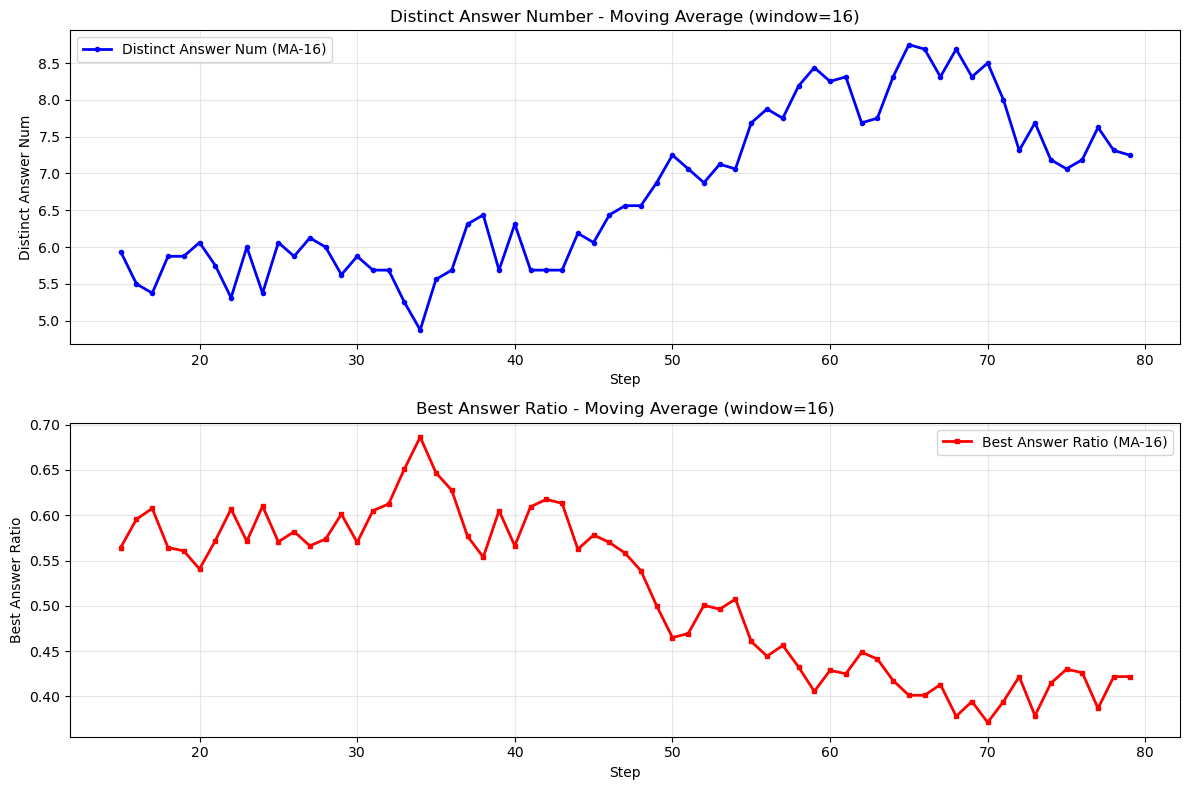

In [26]:
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def extract_diversity_data(filename):
    """
    从文件中提取diversity数据
    """
    distinct_answer_num = []
    best_answer_ratio = []
    
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*best_answer_ratio:\s*([0-9.]+)'
    
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            match = re.search(pattern, line)
            if match:
                distinct_answer_num.append(int(match.group(1)))
                best_answer_ratio.append(float(match.group(2)))
    
    # 使用数据点索引作为步数 (0, 1, 2, ...)
    steps = list(range(len(distinct_answer_num)))
    
    return steps, distinct_answer_num, best_answer_ratio

def moving_average(data, window_size=5):
    """计算滑动平均"""
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def plot_with_moving_average(steps, distinct_answer_num, best_answer_ratio, window_size=5):
    """
    绘制两个图表，都使用滑动平均
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # 计算滑动平均
    ma_distinct = moving_average(distinct_answer_num, window_size)
    ma_best = moving_average(best_answer_ratio, window_size)
    ma_steps = steps[window_size-1:]
    
    # 图1: distinct_answer_num with moving average
    ax1.plot(ma_steps, ma_distinct, 'b-', linewidth=2, marker='o', markersize=3, 
             label=f'Distinct Answer Num (MA-{window_size})')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Distinct Answer Num')
    ax1.set_title(f'Distinct Answer Number - Moving Average (window={window_size})')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 图2: best_answer_ratio with moving average
    ax2.plot(ma_steps, ma_best, 'r-', linewidth=2, marker='s', markersize=3,
             label=f'Best Answer Ratio (MA-{window_size})')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Best Answer Ratio')
    ax2.set_title(f'Best Answer Ratio - Moving Average (window={window_size})')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


# 指定输入文件名
input_file = '/Users/mc03002/Documents/JustGRPO/logs/checkpoints_math500_num_generation16_t0.5_lr1e-6.log'  # 请替换为实际文件名


# 提取数据
steps, distinct_answer_num, best_answer_ratio = extract_diversity_data(input_file)

# 设置滑动窗口大小
window_size = 16  # 可以修改这个值来调整平滑程度

# 绘制带滑动平均的图表
plot_with_moving_average(steps, distinct_answer_num, best_answer_ratio, window_size)


对比不同解码方式的rollout

In [44]:
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def parse_diversity_line(line):
    """
    解析单行diversity数据
    """
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*?all_answer_num:\s*(\d+).*?best_answer_ratio:\s*([0-9.]+).*?correct_answer_number:\s*(\d+).*?best_is_correct:\s*(\d+)'
    match = re.search(pattern, line)
    
    if match:
        return {
            'distinct_answer_num': int(match.group(1)),
            'all_answer_num': int(match.group(2)),
            'best_answer_ratio': float(match.group(3)),
            'correct_answer_number': int(match.group(4)),
            'best_is_correct': int(match.group(5))
        }
    return None

def calculate_metrics(data_list):
    """
    从数据列表中计算各项指标
    """
    if not data_list:
        return {
            'avg_distinct_num': 0,
            'avg_best_ratio': 0,
            'avg_correct_num': 0,
            'avg_accuracy': 0,
            'voting_accuracy': 0,
            'consistency': 0,
            'num_samples': 0
        }
    
    n = len(data_list)
    all_answer_num = data_list[0]['all_answer_num']  # 假设所有行都一样
    
    # 计算平均不同答案数量
    avg_distinct_num = np.mean([d['distinct_answer_num'] for d in data_list])
    
    # 计算平均最佳答案比例 (consistency)
    avg_best_ratio = np.mean([d['best_answer_ratio'] for d in data_list])
    
    # 计算平均正确数量
    avg_correct_num = np.mean([d['correct_answer_number'] for d in data_list])
    
    # 计算所有rollout的准确率
    # 每个样本的总答案数 = all_answer_num
    # 平均正确数 / 总答案数 = 平均准确率
    avg_accuracy = avg_correct_num / all_answer_num
    
    # 计算voting rollouts的准确率 (best_is_correct的比例)
    voting_accuracy = np.mean([d['best_is_correct'] for d in data_list])
    
    return {
        'avg_distinct_num': avg_distinct_num,
        'avg_best_ratio': avg_best_ratio,
        'avg_correct_num': avg_correct_num,
        'avg_accuracy': avg_accuracy,
        'voting_accuracy': voting_accuracy,
        'consistency': avg_best_ratio,  # best_answer_ratio 就是 consistency
        'num_samples': n
    }

def process_file(filename):
    """
    处理单个文件，提取diversity数据并计算指标
    """
    data_list = []
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
    except FileNotFoundError:
        print(f"Warning: File {filename} not found")
        return None
    
    if not data_list:
        print(f"Warning: No diversity data found in {filename}")
        return None
    
    metrics = calculate_metrics(data_list)
    metrics['filename'] = Path(filename).name
    
    return metrics

def print_metrics_table(metrics_list):
    """
    打印指标表格
    """
    print("\n" + "="*100)
    print(f"{'File':<50} {'Samples':<8} {'Distinct#':<10} {'Consistency':<12} {'Rollout Acc':<12} {'Voting Acc':<12}")
    print("="*100)
    
    for metrics in metrics_list:
        if metrics:
            filename = metrics['filename'][:50]  # 截断长文件名
            print(f"{filename:<50} {metrics['num_samples']:<8} "
                  f"{metrics['avg_distinct_num']:<10.2f} "
                  f"{metrics['consistency']:<12.3f} "
                  f"{metrics['avg_accuracy']:<12.3f} "
                  f"{metrics['voting_accuracy']:<12.3f}")
    
    print("="*100)

def plot_comparison_bar_chart(metrics_list):
    """
    绘制对比柱状图，横坐标为rollout_block_size
    """
    # 准备数据 - 假设metrics_list的顺序是 [block1, block32, block256]
    block_sizes = ['1', '32', '256']
    
    # 指标数据
    distinct_nums = [m['avg_distinct_num'] for m in metrics_list if m]
    consistencies = [m['consistency'] for m in metrics_list if m]
    rollout_accs = [m['avg_accuracy'] for m in metrics_list if m]
    voting_accs = [m['voting_accuracy'] for m in metrics_list if m]
    
    # 设置图形
    fig, axes = plt.subplots(2, 2, figsize=(6, 5))
    fig.suptitle('Comparison of Different Metrics Across Rollout Block Sizes', fontsize=16, fontweight='bold')
    
    x = np.arange(len(block_sizes))
    width = 0.6
    
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
    
    # 1. Average Distinct Answer Number
    ax1 = axes[0, 0]
    bars1 = ax1.bar(x, distinct_nums, width, color=colors[0], edgecolor='black', linewidth=1)
    ax1.set_xlabel('Rollout Block Size', fontsize=12)
    ax1.set_ylabel('Distinct Answer', fontsize=12)
    ax1.set_title('Rollout Diversity', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(block_sizes)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 添加数值标签
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Consistency (best_answer_ratio)
    ax2 = axes[0, 1]
    bars2 = ax2.bar(x, consistencies, width, color=colors[1], edgecolor='black', linewidth=1)
    ax2.set_xlabel('Rollout Block Size', fontsize=12)
    ax2.set_ylabel('Best Answer Ratio', fontsize=12)
    ax2.set_title('Rollout Consistency', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(block_sizes)
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Rollout Accuracy
    ax3 = axes[1, 0]
    bars3 = ax3.bar(x, rollout_accs, width, color=colors[2], edgecolor='black', linewidth=1)
    ax3.set_xlabel('Rollout Block Size', fontsize=12)
    ax3.set_ylabel('Accuracy', fontsize=12)
    ax3.set_title('All Rollouts Accuracy', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(block_sizes)
    ax3.set_ylim(0, 1.1)
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Voting Accuracy
    ax4 = axes[1, 1]
    bars4 = ax4.bar(x, voting_accs, width, color=colors[3], edgecolor='black', linewidth=1)
    ax4.set_xlabel('Rollout Block Size', fontsize=12)
    ax4.set_ylabel('Accuracy', fontsize=12)
    ax4.set_title('Voting Results Accuracy', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(block_sizes)
    ax4.set_ylim(0, 1.1)
    ax4.grid(True, alpha=0.3, axis='y')
    
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_grouped_bar_chart(metrics_list):
    """
    绘制分组柱状图，把四个指标放在一起对比，横坐标为rollout_block_size
    """
    block_sizes = ['1', '32', '256']
    
    # 指标数据
    distinct_nums = [m['avg_distinct_num'] for m in metrics_list if m]
    consistencies = [m['consistency'] for m in metrics_list if m]
    rollout_accs = [m['avg_accuracy'] for m in metrics_list if m]
    voting_accs = [m['voting_accuracy'] for m in metrics_list if m]
    
    # 归一化distinct_num到0-1范围便于比较
    max_distinct = max(distinct_nums) if distinct_nums else 1
    distinct_nums_norm = [d/max_distinct for d in distinct_nums]
    
    # 设置图形
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(block_sizes))
    width = 0.2
    
    # 绘制四个指标的柱状图
    bars1 = ax.bar(x - 1.5*width, distinct_nums_norm, width, label='Diversity (normalized)', color='#FF9999', edgecolor='black')
    bars2 = ax.bar(x - 0.5*width, consistencies, width, label='Consistency', color='#66B2FF', edgecolor='black')
    bars3 = ax.bar(x + 0.5*width, rollout_accs, width, label='Rollout Accuracy', color='#99FF99', edgecolor='black')
    bars4 = ax.bar(x + 1.5*width, voting_accs, width, label='Voting Accuracy', color='#FFCC99', edgecolor='black')
    
    ax.set_xlabel('Rollout Block Size', fontsize=14)
    ax.set_ylabel('Value', fontsize=14)
    ax.set_title('Comparison of All Metrics Across Rollout Block Sizes', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(block_sizes)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 添加数值标签
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()


Processing logs/checkpoints_gsm8k_num_generation8_test.log...
Processing logs/checkpoints_gsm8k_num_generation8_test_block32.log...
Processing logs/checkpoints_gsm8k_num_generation8_test_block256.log...

File                                               Samples  Distinct#  Consistency  Rollout Acc  Voting Acc  
checkpoints_gsm8k_num_generation8_test.log         80       3.16       0.691        0.673        0.838       
checkpoints_gsm8k_num_generation8_test_block32.log 80       1.85       0.855        0.803        0.850       
checkpoints_gsm8k_num_generation8_test_block256.lo 80       1.94       0.818        0.534        0.550       


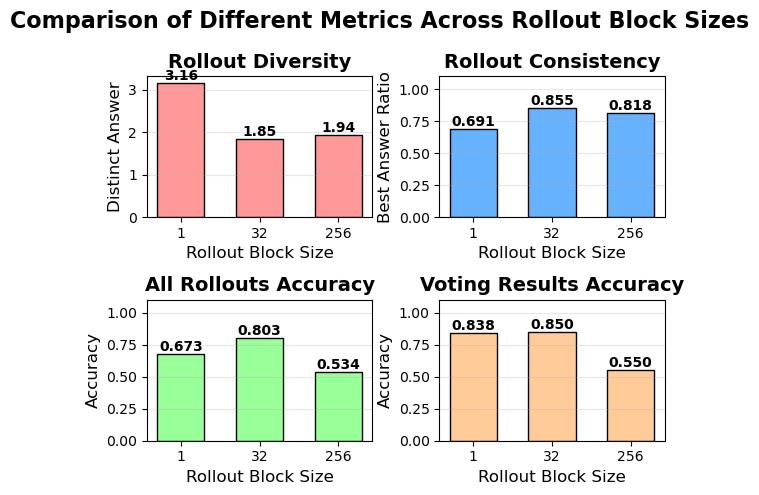

In [45]:

# 指定三个日志文件
log_files = [
        'logs/checkpoints_gsm8k_num_generation8_test.log',           # block size 1 (没有block后缀的)
        'logs/checkpoints_gsm8k_num_generation8_test_block32.log',   # block size 32
        'logs/checkpoints_gsm8k_num_generation8_test_block256.log'   # block size 256
]

# 处理每个文件
metrics_list = []
for log_file in log_files:
    print(f"Processing {log_file}...")
    metrics = process_file(log_file)
    if metrics:
        metrics_list.append(metrics)


# 打印表格
print_metrics_table(metrics_list)

# 绘制对比柱状图
plot_comparison_bar_chart(metrics_list)

# 也可以绘制分组柱状图（可选）
# plot_grouped_bar_chart(metrics_list)

